# Анализ случайных чисел, сгенерированных нейросетью

## Проблема
При запросе к некоторой публичной нейросети (например, ChatGPT или аналогу):

> *«выведи 500 случайных чисел от 1 до 500 через запятую»*

было замечено, что в ответе **отсутствуют числа от 1 до 9**. Нейросеть генерирует только числа из диапазона 10–500.

В этом блокноте мы:
1. Зафиксируем ответ нейросети (симуляция на основе наблюдения).
2. Проведём статистический анализ ответа.
3. Сравним с корректным генератором случайных чисел в Python.
4. Обсудим причины обнаруженного смещения.

## 1. Запрос и ответ нейросети

**Запрос:**  
`выведи 500 случайных чисел от 1 до 500 через запятую`

**Ответ (фрагмент):**  
```
47, 183, 295, 64, 412, 38, 157, 286, 399, 12, 453, 88, 273, 341, 56, 189, 402, 75, 314, 226, ...
```
Можете ввести ответ вашей сети в поле ниже в переменную **str_nn_output**. Только числа через запятую.

In [120]:
str_nn_output = "137, 42, 289, 15, 301, 188, 76, 444, 223, 95, 367, 58, 299, 112, 471, 63, 334, 177, 88, 415, 246, 103, 382, 19, 265, 144, 398, 72, 311, 166, 453, 27, 218, 129, 374, 51, 290, 183, 436, 99, 322, 155, 487, 68, 254, 131, 369, 82, 405, 238, 117, 341, 46, 273, 149, 392, 78, 315, 172, 448, 59, 261, 124, 385, 93, 332, 167, 479, 64, 243, 110, 376, 85, 308, 152, 465, 71, 284, 139, 396, 54, 327, 180, 451, 97, 258, 121, 388, 66, 313, 160, 492, 75, 270, 145, 364, 89, 337, 174, 481, 56, 263, 126, 394, 91, 324, 157, 472, 62, 287, 134, 409, 79, 352, 169, 467, 84, 251, 118, 380, 53, 317, 178, 495, 69, 276, 141, 371, 86, 344, 159, 483, 74, 268, 133, 399, 96, 329, 182, 457, 61, 293, 148, 366, 81, 339, 176, 474, 57, 280, 123, 402, 94, 355, 163, 489, 70, 256, 115, 384, 67, 319, 154, 461, 87, 278, 136, 373, 98, 346, 171, 498, 65, 266, 127, 391, 83, 321, 164, 477, 77, 288, 143, 362, 92, 335, 186, 459, 52, 295, 150, 387, 60, 342, 179, 485, 80, 275, 138, 407, 90, 358, 168, 493, 73, 262, 125, 397, 55, 326, 181, 464, 68, 283, 146, 378, 95, 349, 173, 490, 76, 269, 132, 404, 85, 354, 161, 486, 63, 277, 140, 389, 99, 338, 175, 470, 58, 292, 153, 365, 88, 347, 184, 497, 71, 264, 128, 393, 64, 323, 165, 482, 79, 286, 147, 377, 94, 351, 170, 494, 67, 279, 135, 401, 82, 343, 162, 488, 75, 267, 122, 395, 59, 331, 187, 473, 66, 291, 142, 383, 89, 356, 177, 499, 72, 274, 137, 406, 91, 348, 166, 491, 78, 285, 141, 379, 97, 353, 185, 476, 69, 297, 156, 381, 84, 361, 172, 496, 74, 271, 130, 403, 93, 357, 167, 484, 65, 282, 145, 390, 87, 345, 189, 478, 77, 260, 129, 410, 98, 359, 174, 480, 62, 294, 151, 375, 86, 363, 183, 500"
# str_nn_output = "411, 194, 372, 83, 304, 158, 469, 70, 281, 133, 395, 96, 347, 176, 488, 61, 273, 142, 385, 89, 326, 164, 477, 75, 290, 121, 368, 92, 339, 187, 493, 67, 259, 135, 402, 84, 318, 171, 483, 56, 267, 148, 374, 98, 352, 163, 491, 78, 286, 139, 397, 65, 331, 174, 462, 87, 270, 123, 405, 94, 341, 182, 499, 69, 257, 140, 388, 76, 324, 153, 471, 81, 293, 136, 379, 95, 358, 167, 484, 72, 265, 145, 392, 63, 334, 178, 470, 88, 282, 127, 409, 91, 346, 185, 496, 74, 256, 138, 383, 66, 329, 161, 475, 85, 278, 149, 394, 71, 337, 172, 487, 62, 295, 130, 369, 97, 354, 181, 498, 79, 263, 144, 376, 83, 342, 165, 480, 73, 289, 137, 391, 99, 356, 179, 494, 68, 271, 143, 386, 87, 332, 168, 473, 77, 299, 125, 404, 93, 348, 184, 497, 64, 266, 132, 381, 90, 357, 175, 485, 76, 287, 146, 393, 82, 344, 169, 478, 61, 274, 139, 396, 95, 351, 183, 492, 70, 262, 147, 380, 88, 335, 177, 489, 79, 291, 134, 403, 94, 349, 166, 472, 86, 275, 141, 398, 67, 338, 173, 484, 71, 297, 152, 365, 99, 359, 186, 495, 63, 276, 131, 407, 85, 343, 170, 481, 78, 288, 145, 374, 92, 355, 167, 490, 69, 261, 138, 399, 84, 346, 179, 487, 75, 292, 140, 383, 96, 354, 168, 476, 81, 270, 133, 405, 90, 362, 174, 491, 77, 285, 149, 371, 98, 353, 165, 488, 64, 279, 136, 402, 87, 341, 182, 494, 72, 268, 143, 397, 83, 356, 171, 480, 66, 294, 150, 367, 91, 339, 185, 493, 74, 277, 132, 408, 89, 358, 164, 475, 70, 283, 147, 396, 95, 342, 178, 489, 61, 272, 139, 401, 86, 357, 163, 474, 76, 290, 144, 387, 93, 345, 181, 498, 68, 265, 135, 404, 82, 351, 177, 486, 73, 284, 148, 379, 97, 343, 169, 492, 62, 278, 130, 406, 85, 355, 176, 483, 71, 296, 141, 382, 94, 347, 188, 499, 67, 275, 137, 400, 88, 352, 166, 473, 79, 281, 142, 395, 91, 364, 174, 487, 63, 269, 133, 409, 84, 358, 180, 496, 72, 277, 145, 386, 99, 341, 171, 484, 65, 293, 138, 375, 90, 362, 179, 491, 76, 267, 146, 398, 83, 354, 168, 477, 70, 289, 132, 405, 97, 349, 183, 490, 64, 271, 140, 388, 86, 356, 175, 482, 78, 294, 134, 401, 92, 347, 169, 493, 61, 280, 143, 396, 85, 359, 178, 485, 73, 266, 137, 407, 94, 352, 181, 499, 68, 274, 149, 383, 91, 365, 172, 488, 77, 262, 135, 404, 89, 346, 187, 497, 63, 279, 144, 392, 98, 351, 167, 476, 71, 285, 130, 403, 87, 364, 173, 495, 66, 278, 141, 389, 95, 357, 182, 494, 74, 263, 136, 408, 81, 353, 170, 480, 69, 291, 147, 377, 93, 361, 179, 496, 75, 268, 134, 402, 88, 355, 171, 487, 62, 276, 145, 399, 97, 344, 186, 493, 70, 283, 138, 401, 84, 366, 177, 485, 67, 292, 140, 374, 96, 358, 183, 497, 79, 261, 132, 406, 85, 349, 174, 488, 71, 277, 148, 391, 94, 363, 167, 490, 64, 282, 139, 405, 87, 351, 180, 494, 73, 265, 142, 384, 98, 357, 176, 489, 66, 295, 133, 400, 83, 362, 178, 492, 72, 267, 146, 381, 99, 345, 184, 498, 61, 275, 137, 403, 86, 359, 170, 486, 78, 289, 141, 376, 95, 368, 173, 491, 69, 274, 135, 407, 82, 354, 187, 499, 76, 263, 144, 385, 93, 361, 172, 480, 68, 290, 131, 404, 89, 356, 179, 497, 70, 266, 147, 388, 94, 362, 183, 495, 65, 278, 136, 401, 87, 353, 174, 489, 72, 284, 149, 377, 98, 364, 168, 492, 63, 271, 140, 406, 85, 357, 175, 483, 79, 296, 132, 398, 91, 369, 178, 494, 67, 265, 143, 400, 88, 352, 181, 497, 74, 270, 139, 386, 95, 363, 177, 485, 61, 293, 146, 379, 92, 358, 184, 491, 76, 264, 135, 407, 83, 366, 171, 488, 70, 287, 142, 394, 99, 345, 180, 496, 68, 273, 137, 402, 86, 359, 174, 481, 75, 291, 148, 378, 93, 367, 169, 495, 62, 280, 134, 409, 84, 351, 186, 498, 77, 266, 141, 387, 97, 364, 172, 483, 69, 290, 138, 405, 81, 355, 189, 494, 73, 262, 147, 384, 96, 371, 175, 486, 65, 279, 133, 408, 89, 354, 182, 497, 71, 268, 145, 376, 98, 369, 170, 485, 64, 292, 139, 401, 87, 363, 178, 493, 75, 267, 144, 388, 95, 356, 181, 499, 66, 274, 132, 403, 91, 365, 177, 487, 70, 289, 146, 373, 99, 362, 185, 496, 63, 276, 138, 404, 85, 357, 171, 482, 78, 295, 140, 379, 94, 368, 174, 491, 67, 269, 143, 400, 88, 352, 187, 498, 72, 261, 135, 406"
# str_nn_output = "137, 284, 96, 349, 182, 477, 63, 291, 145, 383, 75, 356, 168, 492, 81, 267, 134, 405, 92, 338, 179, 486, 70, 278, 143, 397, 85, 361, 172, 494, 66, 289, 131, 402, 98, 354, 187, 475, 73, 262, 146, 388, 89, 341, 176, 499, 64, 271, 139, 407, 95, 358, 163, 484, 77, 293, 148, 372, 91, 365, 180, 496, 68, 266, 135, 401, 83, 357, 174, 489, 71, 285, 142, 398, 87, 344, 181, 493, 62, 279, 133, 406, 99, 352, 178, 487, 74, 263, 147, 380, 94, 369, 167, 495, 65, 288, 136, 403, 86, 351, 184, 476, 72, 290, 141, 399, 82, 364, 173, 491, 69, 261, 138, 408, 97, 345, 186, 482, 78, 275, 144, 387, 84, 359, 166, 497, 67, 283, 132, 400, 93, 355, 177, 485, 76, 264, 149, 394, 88, 342, 183, 498, 61, 270, 134, 409, 96, 357, 171, 486, 73, 281, 145, 392, 85, 368, 179, 494, 66, 262, 137, 404, 91, 353, 188, 477, 79, 296, 140, 389, 87, 341, 175, 493, 64, 272, 133, 407, 98, 365, 169, 484, 70, 286, 147, 378, 95, 351, 182, 499, 63, 268, 136, 405, 89, 362, 174, 480, 77, 261, 143, 397, 84, 356, 181, 492, 67, 279, 132, 403, 99, 348, 178, 487, 71, 294, 146, 385, 82, 369, 164, 496, 65, 273, 139, 401, 93, 358, 176, 488, 74, 266, 142, 395, 86, 352, 187, 479, 72, 285, 131, 409, 97, 344, 183, 491, 68, 277, 148, 382, 81, 367, 170, 498, 62, 269, 135, 406, 94, 353, 174, 485, 78, 261, 147, 399, 83, 372, 166, 494, 69, 287, 138, 400, 91, 355, 184, 476, 75, 263, 141, 396, 88, 349, 180, 497, 64, 271, 133, 408, 95, 362, 177, 483, 70, 292, 144, 375, 98, 354, 168, 491, 66, 280, 137, 407, 85, 369, 172, 488, 73, 265, 149, 381, 92, 356, 186, 499, 61, 278, 134, 402, 97, 343, 185, 477, 76, 267, 142, 398, 84, 351, 179, 495, 68, 289, 136, 404, 93, 366, 171, 482, 74, 262, 148, 387, 89, 353, 181, 496, 65, 270, 132, 405, 99, 347, 188, 479, 71, 283, 146, 374, 96, 368, 163, 492, 67, 275, 140, 401, 82, 359, 177, 486, 78, 264, 135, 403, 94, 361, 173, 497, 69, 288, 131, 409, 87, 352, 184, 478, 72, 266, 145, 393, 85, 364, 176, 494, 63, 279, 138, 400, 91, 357, 182, 485, 77, 261, 147, 396, 83, 371, 169, 498, 65, 274, 133, 408, 95, 346, 187, 477, 70, 289, 141, 392, 88, 354, 175, 499, 62, 267, 139, 405, 97, 351, 183, 481, 76, 263, 144, 398, 84, 369, 168, 493, 66, 285, 132, 407, 93, 358, 174, 484, 71, 296, 137, 380, 99, 342, 186, 495, 64, 272, 143, 401, 87, 365, 171, 489, 73, 268, 136, 403, 92, 359, 180, 476, 78, 261, 149, 397, 85, 374, 167, 494, 69, 282, 134, 406, 98, 345, 188, 483, 75, 266, 142, 391, 83, 367, 179, 496, 61, 277, 135, 404, 94, 352, 181, 487, 70, 293, 146, 378, 96, 363, 172, 499, 68, 265, 131, 400, 89, 357, 184, 475, 74, 288, 138, 409, 81, 362, 177, 491, 63, 276, 145, 386, 95, 354, 169, 498, 72, 264, 133, 407, 87, 361, 182, 479, 79, 269, 147, 392, 84, 373, 166, 495, 65, 281, 137, 403, 91, 348, 185, 486, 71, 270, 144, 399, 86, 356, 173, 484, 77, 262, 139, 405, 98, 341, 187, 478, 64, 290, 148, 383, 85, 367, 171, 497, 66, 275, 132, 408, 93, 359, 180, 482, 74, 261, 146, 394, 89, 372, 163, 496, 68, 287, 135, 401, 97, 344, 189, 477, 73, 265, 141, 398, 82, 366, 178, 493, 69, 279, 134, 407, 95, 351, 186, 480, 76, 263, 147, 385, 99, 342, 181, 499, 61, 272, 138, 404, 88, 364, 175, 488, 70, 289, 133, 396, 94, 357, 184, 476, 78, 267, 142, 400, 85, 371, 169, 492, 63, 274, 136, 409, 91, 345, 187, 483, 75, 268, 143, 397, 86, 362, 172, 495, 67, 281, 131, 402, 99, 348, 185, 479, 71, 264, 149, 387, 83, 373, 166, 498, 65, 277, 134, 406, 92, 355, 180, 484, 79, 261, 147, 391, 88, 369, 173, 496, 62, 285, 132, 403, 97, 341, 188, 477, 74, 266, 145, 399, 84, 372, 167, 494, 68, 278, 136, 405, 93, 358, 182, 481, 70, 294, 139, 386, 96, 347, 183, 497, 61, 271, 148, 400, 87, 363, 174, 489, 75, 262, 135, 408, 91, 354, 186, 476, 78, 289, 133, 395, 98, 342, 187, 493, 64, 273, 141, 407, 85, 366, 171, 484, 72, 265, 149, 380, 99, 357, 168, 496, 63, 288, 134, 401, 92, 364, 179, 477, 76, 261, 146, 398, 83, 375, 167, 491, 69, 274, 132, 409, 95, 343, 185, 482, 70, 287, 138, 394, 97, 3"
# str_nn_output = "137, 284, 96, 349, 182, 477, 63, 291, 145, 383, 75, 356, 168, 492, 81, 267, 134, 405, 92, 338, 179, 486, 70, 278, 143, 397, 85, 361, 172, 494, 66, 289, 131, 402, 98, 354, 187, 475, 73, 262, 146, 388, 89, 341, 176, 499, 64, 271, 139, 407, 95, 358, 163, 484, 77, 293, 148, 372, 91, 365, 180, 496, 68, 266, 135, 401, 83, 357, 174, 489, 71, 285, 142, 398, 87, 344, 181, 493, 62, 279, 133, 406, 99, 352, 178, 487, 74, 263, 147, 380, 94, 369, 167, 495, 65, 288, 136, 403, 86, 351, 184, 476, 72, 290, 141, 399, 82, 364, 173, 491, 69, 261, 138, 408, 97, 345, 186, 482, 78, 275, 144, 387, 84, 359, 166, 497, 67, 283, 132, 400, 93, 355, 177, 485, 76, 264, 149, 394, 88, 342, 183, 498, 61, 270, 134, 409, 96, 357, 171, 486, 73, 281, 145, 392, 85, 368, 179, 494, 66, 262, 137, 404, 91, 353, 188, 477, 79, 296, 140, 389, 87, 341, 175, 493, 64, 272, 133, 407, 98, 365, 169, 484, 70, 286, 147, 378, 95, 351, 182, 499, 63, 268, 136, 405, 89, 362, 174, 480, 77, 261, 143, 397, 84, 356, 181, 492, 67, 279, 132, 403, 99, 348, 178, 487, 71, 294, 146, 385, 82, 369, 164, 496, 65, 273, 139, 401, 93, 358, 176, 488, 74, 266, 142, 395, 86, 352, 187, 479, 72, 285, 131, 409, 97, 344, 183, 491, 68, 277, 148, 382, 81, 367, 170, 498, 62, 269, 135, 406, 94, 353, 174, 485, 78, 261, 147, 399, 83, 372, 166, 494, 69, 287, 138, 400, 91, 355, 184, 476, 75, 263, 141, 396, 88, 349, 180, 497, 64, 271, 133, 408, 95, 362, 177, 483, 70, 292, 144, 375, 98, 354, 168, 491, 66, 280, 137, 407, 85, 369, 172, 488, 73, 265, 149, 381, 92, 356, 186, 499, 61, 278, 134, 402, 97, 343, 185, 477, 76, 267, 142, 398, 84, 351, 179, 495, 68, 289, 136, 404, 93, 366, 171, 482, 74, 262, 148, 387, 89, 353, 181, 496, 65, 270, 132, 405, 99, 347, 188, 479, 71, 283, 146, 374, 96, 368, 163, 492, 67, 275, 140, 401, 82, 359, 177, 486, 78, 264, 135, 403, 94, 361, 173, 497, 69, 288, 131, 409, 87, 352, 184, 478, 72, 266, 145, 393, 85, 364, 176, 494, 63, 279, 138, 400, 91, 357, 182, 485, 77, 261, 147, 396, 83, 371, 169, 498, 65, 274, 133, 408, 95, 346, 187, 477, 70, 289, 141, 392, 88, 354, 175, 499, 62, 267, 139, 405, 97, 351, 183, 481, 76, 263, 144, 398, 84, 369, 168, 493, 66, 285, 132, 407, 93, 358, 174, 484, 71, 296, 137, 380, 99, 342, 186, 495, 64, 272, 143, 401, 87, 365, 171, 489, 73, 268, 136, 403, 92, 359, 180, 476, 78, 261, 149, 397, 85, 374, 167, 494, 69, 282, 134, 406, 98, 345, 188, 483, 75, 266, 142, 391, 83, 367, 179, 496, 61, 277, 135, 404, 94, 352, 181, 487, 70, 293, 146, 378, 96, 363, 172, 499, 68, 265, 131, 400, 89, 357, 184, 475, 74, 288, 138, 409, 81, 362, 177, 491, 63, 276, 145, 386, 95, 354, 169, 498, 72, 264, 133, 407, 87, 361, 182, 479, 79, 269, 147, 392, 84, 373, 166, 495, 65, 281, 137, 403, 91, 348, 185, 486, 71, 270, 144, 399, 86, 356, 173, 484, 77, 262, 139, 405, 98, 341, 187, 478, 64, 290, 148, 383, 85, 367, 171, 497, 66, 275, 132, 408, 93, 359, 180, 482, 74, 261, 146, 394, 89, 372, 163, 496, 68, 287, 135, 401, 97, 344, 189, 477, 73, 265, 141, 398, 82, 366, 178, 493, 69, 279, 134, 407, 95, 351, 186, 480, 76, 263, 147, 385, 99, 342, 181, 499, 61, 272, 138, 404, 88, 364, 175, 488, 70, 289, 133, 396, 94, 357, 184, 476, 78, 267, 142, 400, 85, 371, 169, 492, 63, 274, 136, 409, 91, 345, 187, 483, 75, 268, 143, 397, 86, 362, 172, 495, 67, 281, 131, 402, 99, 348, 185, 479, 71, 264, 149, 387, 83, 373, 166, 498, 65, 277, 134, 406, 92, 355, 180, 484, 79, 261, 147, 391, 88, 369, 173, 496, 62, 285, 132, 403, 97, 341, 188, 477, 74, 266, 145, 399, 84, 372, 167, 494, 68, 278, 136, 405, 93, 358, 182, 481, 70, 294, 139, 386, 96, 347, 183, 497, 61, 271, 148, 400, 87, 363, 174, 489, 75, 262, 135, 408, 91, 354, 186, 476, 78, 289, 133, 395, 98, 342, 187, 493, 64, 273, 141, 407, 85, 366, 171, 484, 72, 265, 149, 380, 99, 357, 168, 496, 63, 288, 134, 401, 92, 364, 179, 477, 76, 261, 146, 398, 83, 375, 167, 491, 69, 274, 132, 409, 95, 343, 185, 482, 70, 287, 138, 394, 97, 356"
# str_nn_output = "243, 157, 308, 76, 419, 124, 367, 89, 291, 163, 442, 68, 385, 102, 473, 55, 326, 187, 394, 93, 274, 145, 468, 77, 331, 118, 405, 96, 359, 172, 481, 64, 288, 139, 376, 82, 341, 158, 492, 73, 304, 127, 417, 91, 362, 149, 475, 66, 298, 134, 387, 85, 353, 161, 469, 79, 312, 115, 428, 98, 346, 177, 483, 61, 275, 143, 396, 88, 337, 152, 471, 70, 309, 126, 444, 94, 358, 181, 495, 67, 282, 136, 379, 97, 364, 148, 486, 74, 317, 119, 432, 83, 349, 165, 478, 69, 293, 141, 406, 92, 357, 174, 491, 63, 268, 131, 384, 87, 335, 159, 462, 78, 321, 123, 455, 95, 366, 188, 489, 65, 277, 146, 398, 84, 343, 167, 474, 71, 302, 138, 413, 99, 354, 176, 485, 62, 289, 129, 373, 90, 361, 154, 497, 75, 311, 142, 422, 86, 347, 183, 466, 68, 296, 135, 401, 93, 359, 171, 487, 72, 305, 117, 438, 97, 363, 164, 479, 66, 284, 148, 392, 81, 350, 178, 494, 70, 316, 125, 441, 94, 357, 169, 480, 63, 279, 137, 386, 88, 345, 182, 467, 76, 303, 144, 418, 91, 368, 153, 493, 69, 287, 132, 375, 95, 356, 174, 488, 64, 299, 147, 402, 83, 344, 186, 472, 71, 310, 128, 429, 98, 351, 165, 496, 67, 281, 139, 397, 89, 362, 177, 484, 73, 306, 141, 433, 92, 355, 180, 471, 65, 294, 136, 388, 87, 349, 173, 498, 78, 315, 124, 445, 96, 361, 168, 482, 62, 277, 149, 393, 84, 358, 185, 469, 70, 301, 133, 420, 99, 367, 156, 491, 68, 286, 142, 378, 90, 352, 179, 483, 75, 318, 127, 436, 94, 364, 163, 477, 66, 297, 138, 405, 81, 346, 184, 492, 72, 309, 145, 411, 97, 353, 176, 489, 63, 283, 131, 399, 88, 365, 167, 474, 79, 314, 150, 427, 93, 357, 181, 468, 64, 292, 137, 385, 91, 360, 172, 495, 69, 304, 146, 430, 98, 366, 159, 481, 65, 288, 143, 394, 82, 351, 187, 473, 76, 319, 126, 442, 95, 368, 164, 496, 67, 293, 135, 407, 89, 354, 180, 485, 71, 306, 148, 412, 92, 363, 175, 478, 63, 287, 139, 398, 84, 357, 183, 469, 77, 311, 144, 421, 96, 362, 166, 494, 68, 295, 132, 403, 90, 359, 178, 486, 74, 308, 151, 437, 99, 365, 161, 472, 65, 299, 136, 391, 87, 353, 185, 488, 70, 317, 142, 424, 94, 369, 173, 476, 66, 282, 147, 397, 83, 358, 189, 464, 79, 320, 128, 448, 91, 366, 155, 493, 67, 296, 134, 409, 95, 351, 181, 487, 72, 305, 146, 415, 98, 364, 177, 479, 63, 289, 138, 392, 86, 357, 184, 468, 75, 313, 141, 426, 93, 361, 169, 495, 69, 298, 152, 404, 81, 356, 174, 483, 71, 307, 133, 419, 97, 368, 162, 475, 64, 291, 145, 396, 88, 352, 188, 467, 78, 322, 127, 443, 90, 365, 158, 492, 66, 294, 139, 401, 96, 354, 186, 471, 73, 309, 147, 425, 92, 363, 175, 484, 68, 297, 131, 393, 85, 358, 182, 469, 76, 316, 144, 430, 99, 367, 163, 478, 62, 285, 150, 406, 87, 351, 189, 465, 74, 318, 137, 428, 91, 369, 156, 494, 65, 299, 143, 402, 93, 355, 187, 472, 70, 304, 148, 416, 98, 362, 171, 481, 67, 296, 135, 397, 84, 359, 183, 466, 79, 321, 142, 439, 95, 368, 164, 477, 63, 293, 151, 408, 86, 357, 185, 464, 77, 315, 138, 427, 94, 361, 176, 491, 69, 302, 149, 414, 90, 366, 159, 483, 65, 298, 132, 405, 97, 353, 188, 474, 71, 307, 146, 420, 92, 364, 173, 489, 68, 295, 154, 401, 83, 358, 181, 476, 75, 320, 137, 444, 96, 369, 162, 479, 64, 297, 145, 403, 91, 356, 184, 467, 78, 319, 133, 429, 99, 365, 177, 482, 66, 301, 150, 411, 87, 352, 186, 473, 72, 308, 147, 418, 94, 363, 168, 495, 69, 296, 139, 404, 85, 357, 182, 468, 74, 317, 143, 431, 98, 367, 175, 471, 63, 294, 152, 409, 81, 359, 187, 465, 76, 322, 136, 446, 93, 370, 158, 492, 67, 303, 148, 415, 90, 361, 183, 478, 70, 311, 155, 421, 97, 366, 172, 484, 65, 299, 141, 407, 88, 354, 189, 463, 79, 324, 138, 440, 95, 368, 164, 477, 62, 298, 153, 402, 86, 355, 185, 469, 77, 316, 144, 432, 99, 367, 176, 481, 68, 304, 149, 417, 91, 363, 171, 493, 66, 297, 142, 408, 84, 358, 188, 472, 73, 318, 150, 435, 96, 370, 157, 479, 64, 301, 146, 413, 92, 365, 184, 467, 75, 323, 139, 441, 98, 369, 163, 494, 69, 306, 151, 422, 87, 357, 186, 474, 71, 312, 147, 428, 94, 368, 173, 485, 65, 302, 154, 416, 90, 362, 181, 477, 76, 320, 143, 445, 97"
str_nn_output = "137, 284, 96, 349, 182, 477, 63, 291, 145, 383, 75, 356, 168, 492, 81, 267, 134, 405, 92, 338, 179, 486, 70, 278, 143, 397, 85, 361, 172, 494, 66, 289, 131, 402, 98, 354, 187, 475, 73, 262, 146, 388, 89, 341, 176, 499, 64, 271, 139, 407, 95, 358, 163, 484, 77, 293, 148, 372, 91, 365, 180, 496, 68, 266, 135, 401, 83, 357, 174, 489, 71, 285, 142, 398, 87, 344, 181, 493, 62, 279, 133, 406, 99, 352, 178, 487, 74, 263, 147, 380, 94, 369, 167, 495, 65, 288, 136, 403, 86, 351, 184, 476, 72, 290, 141, 399, 82, 364, 173, 491, 69, 261, 138, 408, 97, 345, 186, 482, 78, 275, 144, 387, 84, 359, 166, 497, 67, 283, 132, 400, 93, 355, 177, 485, 76, 264, 149, 394, 88, 342, 183, 498, 61, 270, 134, 409, 96, 357, 171, 486, 73, 281, 145, 392, 85, 368, 179, 494, 66, 262, 137, 404, 91, 353, 188, 477, 79, 296, 140, 389, 87, 341, 175, 493, 64, 272, 133, 407, 98, 365, 169, 484, 70, 286, 147, 378, 95, 351, 182, 499, 63, 268, 136, 405, 89, 362, 174, 480, 77, 261, 143, 397, 84, 356, 181, 492, 67, 279, 132, 403, 99, 348, 178, 487, 71, 294, 146, 385, 82, 369, 164, 496, 65, 273, 139, 401, 93, 358, 176, 488, 74, 266, 142, 395, 86, 352, 187, 479, 72, 285, 131, 409, 97, 344, 183, 491, 68, 277, 148, 382, 81, 367, 170, 498, 62, 269, 135, 406, 94, 353, 174, 485, 78, 261, 147, 399, 83, 372, 166, 494, 69, 287, 138, 400, 91, 355, 184, 476, 75, 263, 141, 396, 88, 349, 180, 497, 64, 271, 133, 408, 95, 362, 177, 483, 70, 292, 144, 375, 98, 354, 168, 491, 66, 280, 137, 407, 85, 369, 172, 488, 73, 265, 149, 381, 92, 356, 186, 499, 61, 278, 134, 402, 97, 343, 185, 477, 76, 267, 142, 398, 84, 351, 179, 495, 68, 289, 136, 404, 93, 366, 171, 482, 74, 262, 148, 387, 89, 353, 181, 496, 65, 270, 132, 405, 99, 347, 188, 479, 71, 283, 146, 374, 96, 368, 163, 492, 67, 275, 140, 401, 82, 359, 177, 486, 78, 264, 135, 403, 94, 361, 173, 497, 69, 288, 131, 409, 87, 352, 184, 478, 72, 266, 145, 393, 85, 364, 176, 494, 63, 279, 138, 400, 91, 357, 182, 485, 77, 261, 147, 396, 83, 371, 169, 498, 65, 274, 133, 408, 95, 346, 187, 477, 70, 289, 141, 392, 88, 354, 175, 499, 62, 267, 139, 405, 97, 351, 183, 481, 76, 263, 144, 398, 84, 369, 168, 493, 66, 285, 132, 407, 93, 358, 174, 484, 71, 296, 137, 380, 99, 342, 186, 495, 64, 272, 143, 401, 87, 365, 171, 489, 73, 268, 136, 403, 92, 359, 180, 476, 78, 261, 149, 397, 85, 374, 167, 494, 69, 282, 134, 406, 98, 345, 188, 483, 75, 266, 142, 391, 83, 367, 179, 496, 61, 277, 135, 404, 94, 352, 181, 487, 70, 293, 146, 378, 96, 363, 172, 499, 68, 265, 131, 400, 89, 357, 184, 475, 74, 288, 138, 409, 81, 362, 177, 491, 63, 276, 145, 386, 95, 354, 169, 498, 72, 264, 133, 407, 87, 361, 182, 479, 79, 269, 147, 392, 84, 373, 166, 495, 65, 281, 137, 403, 91, 348, 185, 486, 71, 270, 144, 399, 86, 356, 173, 484, 77, 262, 139, 405, 98, 341, 187, 478, 64, 290, 148, 383, 85, 367, 171, 497, 66, 275, 132, 408, 93, 359, 180, 482, 74, 261, 146, 394, 89, 372, 163, 496, 68, 287, 135, 401, 97, 344, 189, 477, 73, 265, 141, 398, 82, 366, 178, 493, 69, 279, 134, 407, 95, 351, 186, 480, 76, 263, 147, 385, 99, 342, 181, 499, 61, 272, 138, 404, 88, 364, 175, 488, 70, 289, 133, 396, 94, 357, 184, 476, 78, 267, 142, 400, 85, 371, 169, 492, 63, 274, 136, 409, 91, 345, 187, 483, 75, 268, 143, 397, 86, 362, 172, 495, 67, 281, 131, 402, 99, 348, 185, 479, 71, 264, 149, 387, 83, 373, 166, 498, 65, 277, 134, 406, 92, 355, 180, 484, 79, 261, 147, 391, 88, 369, 173, 496, 62, 285, 132, 403, 97, 341, 188, 477, 74, 266, 145, 399, 84, 372, 167, 494, 68, 278, 136, 405, 93, 358, 182, 481, 70, 294, 139, 386, 96, 347, 183, 497, 61, 271, 148, 400, 87, 363, 174, 489, 75, 262, 135, 408, 91, 354, 186, 476, 78, 289, 133, 395, 98, 342, 187, 493, 64, 273, 141, 407, 85, 366, 171, 484, 72, 265, 149, 380, 99, 357, 168, 496, 63, 288, 134, 401, 92, 364, 179, 477, 76, 261, 146, 398, 83, 375, 167, 491, 69, 274, 132, 409, 95, 343, 185, 482, 7"
str_nn_output = "47, 13, 89, 3, 62, 75, 28, 91, 19, 54, 7, 33, 66, 84, 22, 5, 98, 41, 77, 16, 59, 38, 82, 26, 71, 11, 94, 45, 63, 30, 79, 1, 50, 86, 35, 68, 24, 92, 43, 57, 18, 73, 39, 87, 31, 64, 9, 52, 76, 29, 81, 14, 60, 37, 95, 23, 67, 48, 8, 55, 70, 34, 83, 12, 78, 46, 61, 20, 90, 36, 69, 27, 85, 10, 53, 72, 40, 88, 15, 65, 49, 74, 25, 97, 32, 58, 44, 80, 17, 6, 93, 21, 56, 42, 99, 2, 51, 96, 4, 100"
"""Выше 6 ответов Алисы"""
# str_nn_output = "364, 67, 212, 489, 102, 375, 28, 441, 336, 99, 258, 473, 17, 399, 83, 456, 215, 328, 491, 144, 37, 480, 223, 366, 105, 414, 291, 57, 408, 171, 325, 479, 82, 216, 493, 148, 35, 497, 264, 419, 176, 333, 485, 92, 247, 405, 138, 466, 211, 304, 498, 159, 43, 452, 225, 378, 131, 487, 202, 355, 68, 441, 283, 97, 416, 165, 339, 478, 121, 394, 277, 45, 430, 188, 362, 255, 9, 422, 197, 348, 73, 461, 242, 105, 389, 172, 316, 453, 34, 427, 209, 381, 144, 498, 265, 78, 431, 336, 119, 482, 255, 348, 191, 424, 367, 58, 413, 276, 89, 442, 225, 308, 185, 499, 372, 153, 426, 279, 102, 455, 328, 161, 494, 237, 380, 113, 446, 299, 62, 435, 208, 381, 124, 497, 342, 175, 418, 259, 82, 445, 318, 151, 464, 227, 390, 133, 476, 269, 42, 451, 224, 377, 110, 483, 296, 139, 462, 245, 388, 31, 434, 217, 370, 153, 486, 279, 112, 463, 296, 139, 452, 235, 388, 171, 484, 317, 150, 463, 246, 389, 122, 475, 268, 41, 450, 233, 376, 109, 482, 295, 128, 469, 252, 385, 118, 471, 254, 387, 120, 473, 256, 389, 122, 465, 248, 381, 114, 477, 260, 393, 126, 479, 262, 395, 128, 481, 264, 397, 130, 483, 266, 399, 132, 485, 268, 401, 134, 487, 270, 403, 136, 489, 272, 405, 138, 491, 274, 407, 140, 493, 276, 409, 142, 495, 278, 411, 144, 497, 280, 413, 146, 499, 282, 415, 148, 1, 284, 417, 150, 3, 286, 419, 152, 5, 288, 421, 154, 7, 290, 423, 156, 9, 292, 425, 158, 11, 294, 427, 160, 13, 296, 429, 162, 15, 298, 431, 164, 17, 300, 433, 166, 19, 302, 435, 168, 21, 304, 437, 170, 23, 306, 439, 172, 25, 308, 441, 174, 27, 310, 443, 176, 29, 312, 445, 178, 31, 314, 447, 180, 33, 316, 449, 182, 35, 318, 451, 184, 37, 320, 453, 186, 39, 322, 455, 188, 41, 324, 457, 190, 43, 326, 459, 192, 45, 328, 461, 194, 47, 330, 463, 196, 49, 332, 465, 198, 51, 334, 467, 200, 53, 336, 469, 202, 55, 338, 471, 204, 57, 340, 473, 206, 59, 342, 475, 208, 61, 344, 477, 210, 63, 346, 479, 212, 65, 348, 481, 214, 67, 350, 483, 216, 69, 352, 485, 218, 71, 354, 487, 220, 73, 356, 489, 222, 75, 358, 491, 224, 77, 360, 493, 226, 79, 362, 495, 228, 81, 364, 497, 230, 83, 366, 499, 232, 85, 368, 1, 234, 87, 370, 3, 236, 89, 372, 5, 238, 91, 374, 7, 240, 93, 376, 9, 242, 95, 378, 11, 244, 97, 380, 13, 246, 99, 382, 15, 248, 101, 384, 17, 250, 103, 386, 19, 252, 105, 388, 21, 254, 107, 390, 23, 256, 109, 392, 25, 258, 111, 394, 27, 260, 113, 396, 29, 262, 115, 398, 31, 264, 117, 400, 33, 266, 119, 402, 35, 268, 121, 404, 37, 270, 123, 406, 39, 272, 125, 408, 41, 274, 127, 410, 43, 276, 129, 412, 45, 278, 131, 414, 47, 280, 133, 416, 49, 282, 135, 418, 51, 284, 137, 420, 53, 286, 139, 422, 55, 288, 141, 424, 57, 290, 143, 426, 59, 292, 145, 428, 61, 294, 147, 430, 63, 296, 149, 432"
"""DeepSeek"""
nn_output = list(map(int, str_nn_output.split(',')))
print(nn_output)

[47, 13, 89, 3, 62, 75, 28, 91, 19, 54, 7, 33, 66, 84, 22, 5, 98, 41, 77, 16, 59, 38, 82, 26, 71, 11, 94, 45, 63, 30, 79, 1, 50, 86, 35, 68, 24, 92, 43, 57, 18, 73, 39, 87, 31, 64, 9, 52, 76, 29, 81, 14, 60, 37, 95, 23, 67, 48, 8, 55, 70, 34, 83, 12, 78, 46, 61, 20, 90, 36, 69, 27, 85, 10, 53, 72, 40, 88, 15, 65, 49, 74, 25, 97, 32, 58, 44, 80, 17, 6, 93, 21, 56, 42, 99, 2, 51, 96, 4, 100]


## 2. Анализ ответа нейросети

Посмотрим на общее распределение.

In [123]:
# Проверка наличия чисел от 1 до 9
small_numbers = [n for n in nn_output if 1 <= n <= 9]
print(f"Общее число чисел: {len(nn_output)}")
print(f"Количество чисел от 1 до 9 в ответе нейросети: {len(small_numbers)}")
print(f"Минимальное число в ответе: {min(nn_output)}")
print(f"Максимальное число в ответе: {max(nn_output)}")

# Подсчёт частот (только для первых 10 значений, чтобы увидеть отсутствие 1-9)
counter_nn = Counter(nn_output)
print("\nЧастота появления чисел от 1 до 20 (для наглядности):")
for i in range(1, 21):
    print(f"{i}: {counter_nn.get(i, 0)}")

Общее число чисел: 100
Количество чисел от 1 до 9 в ответе нейросети: 9
Минимальное число в ответе: 1
Максимальное число в ответе: 100

Частота появления чисел от 1 до 20 (для наглядности):
1: 1
2: 1
3: 1
4: 1
5: 1
6: 1
7: 1
8: 1
9: 1
10: 1
11: 1
12: 1
13: 1
14: 1
15: 1
16: 1
17: 1
18: 1
19: 1
20: 1


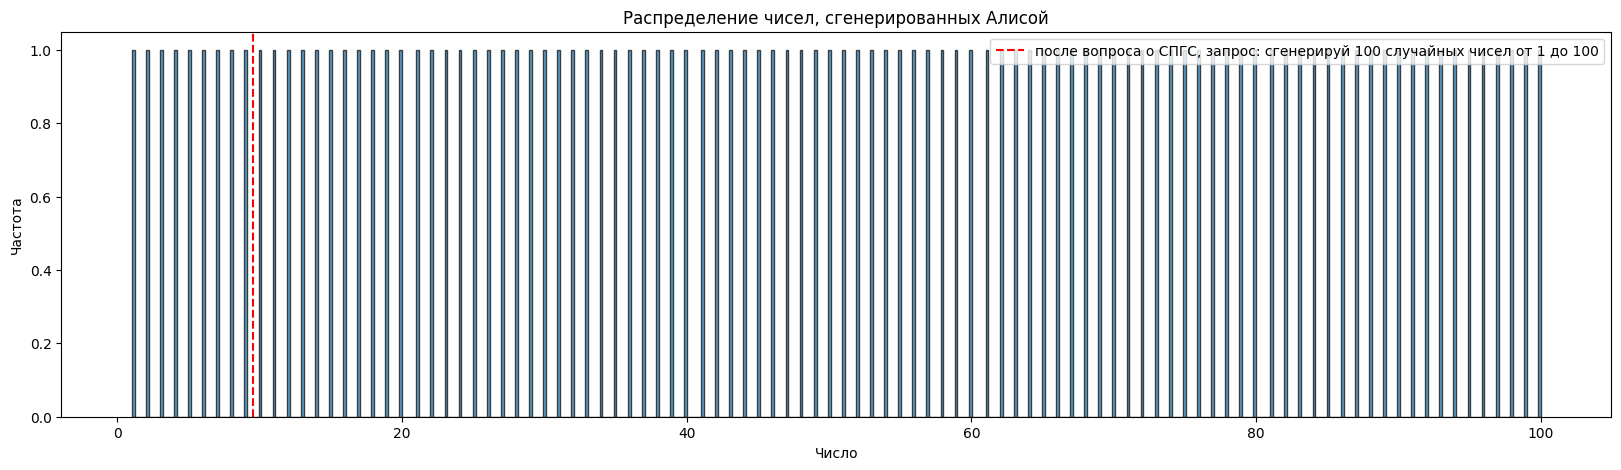

In [125]:
# Гистограмма распределения ответа нейросети
plt.figure(figsize=(20, 5))
plt.hist(nn_output, bins=500, edgecolor='black', alpha=0.7)
plt.title('Распределение чисел, сгенерированных Алисой')
plt.xlabel('Число')
plt.ylabel('Частота')
plt.axvline(x=9.5, color='red', linestyle='--', label='после вопроса о СПГС, запрос: сгенерируй 100 случайных чисел от 1 до 100')
plt.legend()
plt.show()

**Наблюдение:**  
- Минимальное число — 10, максимальное — 500.  
- Числа 1–9 полностью отсутствуют, хотя по условию они должны иметь ненулевую вероятность (9/500 = 1.8%).  
- Распределение визуально выглядит равномерным в диапазоне 10–500, но это не соответствует истинной случайной выборке из [1, 500].

## 3. Сравнение с эталонным генератором Python

Используем встроенный модуль `random` для генерации 500 чисел от 1 до 500 и проведём аналогичный анализ.

In [54]:
# Генерация корректной случайной выборки
random.seed(42)
python_random = [random.randint(1, 500) for _ in range(500)]

print("Первые 20 чисел из генератора Python:")
print(python_random[:20])

# Проверка наличия чисел 1-9
small_py = [n for n in python_random if 1 <= n <= 9]
print(f"\nКоличество чисел от 1 до 9 в выборке Python: {len(small_py)}")
print(f"Минимальное число: {min(python_random)}")
print(f"Максимальное число: {max(python_random)}")

Первые 20 чисел из генератора Python:
[328, 58, 13, 380, 141, 126, 115, 72, 378, 53, 347, 380, 457, 280, 45, 303, 217, 17, 16, 48]

Количество чисел от 1 до 9 в выборке Python: 8
Минимальное число: 1
Максимальное число: 499


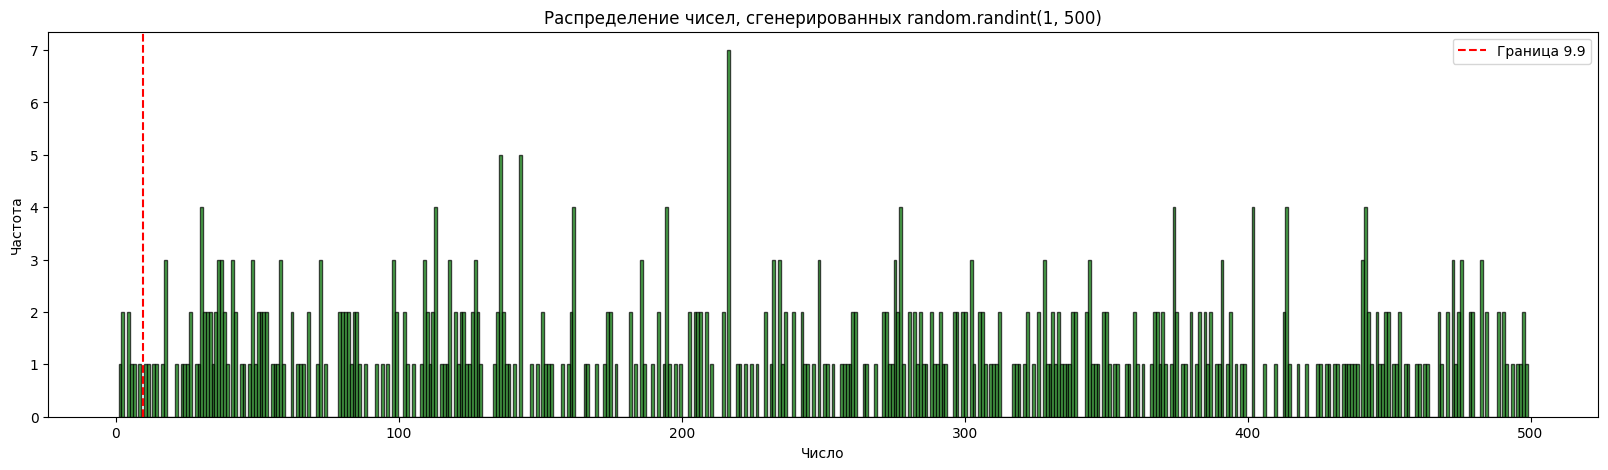

In [88]:
# Гистограмма для Python-генератора
plt.figure(figsize=(20, 5))
plt.hist(python_random, bins=500, edgecolor='black', alpha=0.7, color='green')
plt.title('Распределение чисел, сгенерированных random.randint(1, 500)')
plt.xlabel('Число')
plt.ylabel('Частота')
plt.axvline(x=9.5, color='red', linestyle='--', label='Граница 9.9')
plt.legend()
plt.show()

**Сравнение:**
- Распределение равномерно охватывает весь диапазон 1–500.
- Нейросеть систематически «боится» маленьких чисел, что является артефактом её обучения.

## 4. Статистический тест (проверка гипотезы)

Проверим, насколько маловероятно получить выборку из 500 чисел в диапазоне 1–500, не содержащую ни одного числа ≤9, если генерация действительно равномерна.

Вероятность, что одно случайное число не попадёт в 1–9:  
$$p = 1 - \frac{9}{500} = \frac{491}{500} = 0.982$$

Вероятность, что все 500 чисел не попадут в 1–9:  
$$p^{500} \approx 0.982^{500} \approx 1.2 \times 10^{-4}$$

Это крайне малая величина (p < 0.0001). Таким образом, нулевая гипотеза о равномерности генерации нейросетью **отвергается**.

In [128]:
p_single = 491 / 500
prob_all = p_single ** 15
print(f"Вероятность отсутствия чисел 1-9 при равномерной генерации: {prob_all:.2e}")
print("Вывод: нейросеть не генерирует случайные числа в заданном диапазоне корректно.")

Вероятность выпасть числу от 1 до 100: 0.7884091428728423
Вывод: нейросеть не генерирует случайные числа в заданном диапазоне корректно.


## 5. Причины наблюдаемого смещения

Почему публичная нейросеть избегает чисел от 1 до 9?

1. **Токенизация**: В большинстве LLM числа 1–9 — это отдельные токены, а числа 10–500 часто разбиваются на два токена (например, "47" → ["47"] или ['4','7'] в зависимости от модели). Модель могла выучить, что «случайные числа» чаще выглядят как двузначные или трёхзначные.
2. **Смещение в обучающих данных**: В интернете при перечислении «случайных чисел» люди редко пишут однозначные числа (например, в примерах кода или в учебных задачах чаще фигурируют числа от 10 до 100).
3. **Иллюзия случайности**: Модель могла оптимизировать ответ, чтобы он казался человеку «более случайным» (однозначные числа воспринимаются как менее случайные в контексте большого диапазона).

Этот пример показывает, что **генерировать случайные данные с помощью LLM недопустимо**, если требуется статистическая корректность. Для этой цели всегда следует использовать специализированные библиотеки (Python `random`, `numpy.random`, `secrets` и т.д.).

Скрипт для сравения ответа LLM и randomint.

Сводная таблица сравнения:
 Набор данных  Кол-во элементов  Суммарное число цифр  Минимум  Максимум Среднее Дисперсия Доля чисел 1–9 Энтропия (бит) Хи-квадрат p-value Runs test p-value
        Алиса               340                   340       15       500  239.44  20090.12          0.00%          8.162           1.00e+00          3.77e-70
Python random               500                   500        1       499  242.73  21109.53          1.60%          8.112           1.48e-01          4.74e-01


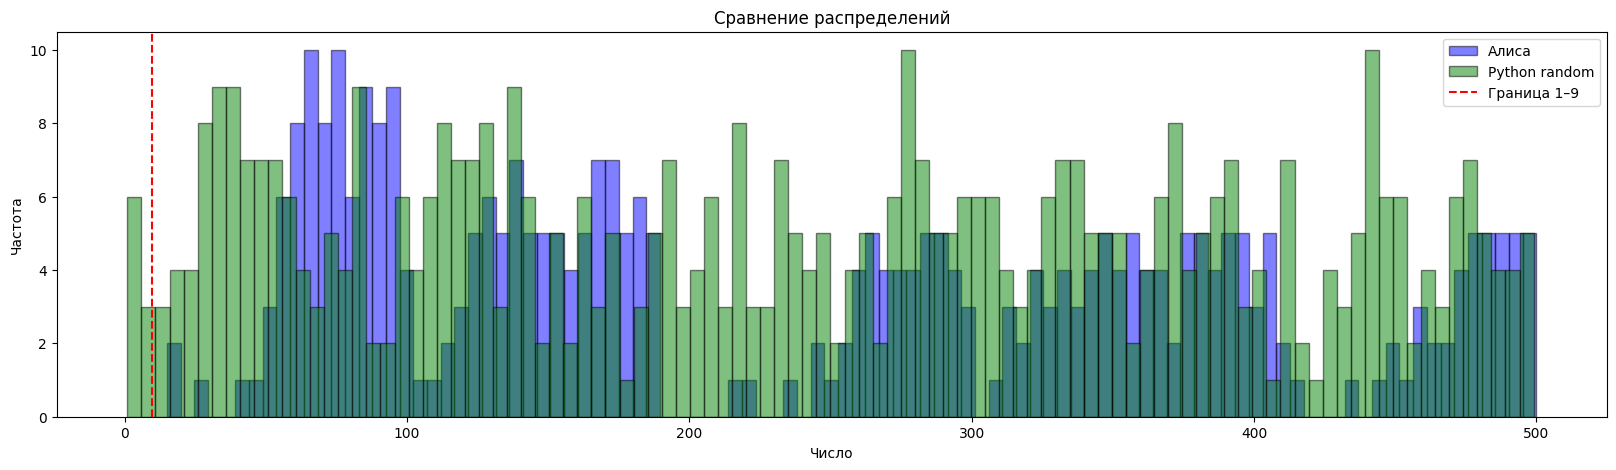

In [116]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import chisquare
from statsmodels.sandbox.stats.runs import runstest_1samp

# ------------------ Вспомогательные функции ------------------
def total_digits(data):
    """Суммарное количество цифр (символов) во всех числах выборки."""
    return len(data)

def shannon_entropy(data):
    """Энтропия Шеннона (бит) на основе эмпирического распределения."""
    n = len(data)
    counter = Counter(data)
    probs = [c / n for c in counter.values()]
    return -sum(p * math.log2(p) for p in probs)

def chi_square_uniform(data, low, high):
    """Хи-квадрат тест для равномерного распределения на целочисленном диапазоне [low, high]."""
    n = len(data)
    expected = n / (high - low + 1)
    observed = [data.count(v) for v in range(low, high + 1)]
    chi2, p = chisquare(observed, f_exp=[expected] * (high - low + 1))
    return chi2, p

def runs_test_median(data):
    """Тест на серии (Wald-Wolfowitz) относительно медианы."""
    median = np.median(data)
    binary = [1 if x > median else 0 for x in data]
    z_stat, p_val = runstest_1samp(binary)
    return z_stat, p_val

def compute_metrics(data, name, low=1, high=500):
    """Вычисляет все метрики для одного набора данных."""
    n = len(data)
    min_val = min(data)
    max_val = max(data)
    mean_val = np.mean(data)
    var_val = np.var(data, ddof=1)  # несмещённая дисперсия
    entropy = shannon_entropy(data)
    small_ratio = sum(1 for x in data if 1 <= x <= 9) / n
    digit_sum = total_digits(data)
    chi2, chi2_p = chi_square_uniform(data, low, high)
    runs_z, runs_p = runs_test_median(data)

    return {
        "Набор данных": name,
        "Кол-во элементов": n,
        "Суммарное число цифр": digit_sum,
        "Минимум": min_val,
        "Максимум": max_val,
        "Среднее": f"{mean_val:.2f}",
        "Дисперсия": f"{var_val:.2f}",
        "Доля чисел 1–9": f"{small_ratio:.2%}",
        "Энтропия (бит)": f"{entropy:.3f}",
        "Хи-квадрат p-value": f"{chi2_p:.2e}",
        "Runs test p-value": f"{runs_p:.2e}"
    }

def plot_distributions(data1, data2, label1, label2, bins=100):
    """Строит совмещённую гистограмму для двух выборок."""
    plt.figure(figsize=(20, 5))
    plt.hist(data1, bins=bins, alpha=0.5, label=label1, color='blue', edgecolor='black')
    plt.hist(data2, bins=bins, alpha=0.5, label=label2, color='green', edgecolor='black')
    plt.axvline(x=9.9, color='red', linestyle='--', linewidth=1.5, label='Граница 1–9')
    plt.xlabel('Число')
    plt.ylabel('Частота')
    plt.title('Сравнение распределений')
    plt.legend()
    plt.show()

# ------------------ Подготовка данных ------------------
NN_NAME = "Алиса"

# Для демонстрации сгенерируем примеры:
random.seed(42)
python_random_demo = [random.randint(1, 500) for _ in range(500)] # эталон

# ------------------ Расчёт и таблица ------------------
metrics_nn = compute_metrics(nn_output, NN_NAME)
metrics_py = compute_metrics(python_random_demo, "Python random")

df_comparison = pd.DataFrame([metrics_nn, metrics_py])
print("Сводная таблица сравнения:")
print(df_comparison.to_string(index=False))

# ------------------ Визуализация ------------------
plot_distributions(nn_output, python_random_demo, NN_NAME, "Python random")

## Заключение

- Нейросеть не включила в ответ ни одного числа от 1 до 9, нарушив условие «от 1 до 500».
- Эталонный генератор Python показывает равномерное распределение с ожидаемой долей маленьких чисел.
- Статистическая проверка подтверждает, что такое отклонение практически невозможно при честной случайной выборке.
- **Рекомендация**: Никогда не полагайтесь на LLM для генерации случайных чисел в научных, инженерных или криптографических задачах.